# CAM-MPAS: Typhoon Yagi Vertical Cross-Section
## Case: c124_ecomip-p1-golden_clubbmf.002

Typhoon Yagi (September 2024) in a 3.75 km CAM-MPAS simulation.

**What this notebook does:**
1. Scans all h1i (30-min 2D) files for the minimum sea-level pressure (PSL) in the western
   Pacific / South China Sea, efficiently loading only the regional subset of each file.
2. Identifies the timestep where Yagi is best-defined (lowest PSL), prints a ranked table.
3. Loads the matching h0i (30-min 3D) snapshot for that timestep.
4. Produces an overview map (UXarray native-grid polygons, with scatter fallback).
5. Extracts a north–south vertical curtain through the typhoon center longitude.
6. Plots dual-colormap cross-sections of cloud liquid (green) and ice (pink/purple),
   with temperature contours and a tropopause proxy (T = 200 K).

**Yagi track context (Wikipedia):**
- Sept 2: Landfall at Casiguran, Aurora, Philippines (16.3°N, 122.1°E)
- Sept 3: Emerged in South China Sea after crossing Luzon (~16°N, 118–120°E)
- Sept 5: Peak intensity (~907 hPa) — after the simulation ends

The simulation covers 2024-09-02 through 2024-09-04 (96 files × 30-min).

In [1]:
from pathlib import Path
import yaml
import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import uxarray as ux

# ── CASE CONFIGURATION ────────────────────────────────────────────────────────
CASE    = "c124_ecomip-p1-golden_clubbmf.002"
ARCHIVE = Path("/glade/campaign/cesm/km-scale/archive")

# Western Pacific search region for Typhoon Yagi
# Sept 2: Philippine Sea (east of Philippines); Sept 3: South China Sea (west)
SEARCH_LON = (110.0, 135.0)   # °E, 0–360 convention
SEARCH_LAT = (10.0,  25.0)    # °N

# Cross-section display parameters — overwritten in Cell 5 after storm tracking;
# pre-filled with confirmed best values as a fallback for re-runs starting at Cell 6+
LON_CENTER     = 118.0    # °E — typhoon center longitude (filled by storm tracking)
LAT_CENTER     = 17.5     # °N — typhoon center latitude (filled by storm tracking)
LAT_RANGE      = (LAT_CENTER - 8.0, LAT_CENTER + 8.0)   # ±8° N–S window
LON_HALF_WIDTH = 2.0      # ° — half-width of the longitude band
ALT_MAX        = 18_000   # m — cap y-axis to troposphere + lower stratosphere
TARGET_DATE    = "2024-09-03"
TARGET_SECONDS = 72000    # seconds since midnight (20:00 UTC)

# ── GRID FILE & STREAM LOOKUP FROM YAML ───────────────────────────────────────
_cfg_path = Path("/glade/u/home/brianpm/Code/hacknostics/util/km_scale_cases.yaml")
with open(_cfg_path) as _f:
    _cfg = yaml.safe_load(_f)

_case_cfg = _cfg["cases"].get(CASE)
if _case_cfg is None:
    raise ValueError(f"Case {CASE!r} not found in {_cfg_path}")

_grid_key       = _case_cfg["grid"]
_grid_root      = Path(_cfg["grid_files_root"])
GRID_FILE       = _grid_root / _cfg["grids"][_grid_key]["filename"]
SURVEY_STREAM   = _case_cfg["survey_stream"]    # h1i — has PSL, TGCLDIWP (2D, 30-min)
SNAPSHOT_STREAM = _case_cfg["snapshot_stream"]  # h0i — has CLDLIQ, CLDICE, Z3, T (3D, 30-min)

print(f"Case:            {CASE}")
print(f"Grid:            {_grid_key}  ({_cfg['grids'][_grid_key]['resolution_km']} km)")
print(f"Survey stream:   {SURVEY_STREAM}")
print(f"Snapshot stream: {SNAPSHOT_STREAM}")
print(f"Search region:   lon {SEARCH_LON}°E, lat {SEARCH_LAT}°N")

Case:            c124_ecomip-p1-golden_clubbmf.002
Grid:            mpasa3p75  (3.75 km)
Survey stream:   h1i
Snapshot stream: h0i
Search region:   lon (110.0, 135.0)°E, lat (10.0, 25.0)°N


## File Inventory and Grid Mask

In [2]:
case_root = ARCHIVE / CASE / "atm" / "hist"

survey_files   = sorted(case_root.glob(f"{CASE}.cam.{SURVEY_STREAM}.*.nc"))
snapshot_files = sorted(case_root.glob(f"{CASE}.cam.{SNAPSHOT_STREAM}.*.nc"))

print(f"Survey files   ({SURVEY_STREAM}): {len(survey_files)}")
if survey_files:
    print(f"  first: {survey_files[0].name}")
    print(f"  last:  {survey_files[-1].name}")
print(f"Snapshot files ({SNAPSHOT_STREAM}): {len(snapshot_files)}")
if snapshot_files:
    print(f"  first: {snapshot_files[0].name}")
    print(f"  last:  {snapshot_files[-1].name}")

# ── Load lat/lon once from the first survey file ──────────────────────────────
# These coordinates are constant across all files; loading them once avoids
# re-reading 2 × 335 MB per loop iteration.
_ds0    = xr.open_dataset(survey_files[0], engine="netcdf4")
lat_all = _ds0["lat"].values   # shape: (41_943_042,)
lon_all = _ds0["lon"].values   # 0–360 convention
_ds0.close()

print(f"\nGrid: {len(lat_all):,} cells")
print(f"lat:  {lat_all.min():.1f}° to {lat_all.max():.1f}°")
print(f"lon:  {lon_all.min():.1f}° to {lon_all.max():.1f}° (0–360)")

# ── Western Pacific search mask ───────────────────────────────────────────────
_search_mask = (
    (lon_all >= SEARCH_LON[0]) & (lon_all <= SEARCH_LON[1]) &
    (lat_all >= SEARCH_LAT[0]) & (lat_all <= SEARCH_LAT[1])
)
_search_idx  = np.where(_search_mask)[0]   # integer indices — used if isel approach is needed
lat_search   = lat_all[_search_mask]
lon_search   = lon_all[_search_mask]

print(f"\nSearch region: {_search_mask.sum():,} cells  "
      f"(lon {SEARCH_LON[0]}–{SEARCH_LON[1]}°E, lat {SEARCH_LAT[0]}–{SEARCH_LAT[1]}°N)")

Survey files   (h1i): 96
  first: c124_ecomip-p1-golden_clubbmf.002.cam.h1i.2024-09-02-01800.nc
  last:  c124_ecomip-p1-golden_clubbmf.002.cam.h1i.2024-09-04-00000.nc
Snapshot files (h0i): 96
  first: c124_ecomip-p1-golden_clubbmf.002.cam.h0i.2024-09-02-01800.nc
  last:  c124_ecomip-p1-golden_clubbmf.002.cam.h0i.2024-09-04-00000.nc

Grid: 41,943,042 cells
lat:  -90.0° to 90.0°
lon:  0.0° to 360.0° (0–360)

Search region: 364,201 cells  (lon 110.0–135.0°E, lat 10.0–25.0°N)


## Storm Tracking: Find Typhoon Yagi via PSL Minimum

For each h1i file we extract **only the cells in the western Pacific search region** (~0.9% of
the 41.9M-cell grid). PSL (sea-level pressure) is a 2D field (no vertical dimension), so each
regional extraction is ~1.4 MB — much more efficient than loading the full file.

We track the minimum PSL location at each timestep, then rank by PSL ascending to find the
most intensely developed typhoon snapshot.

In [3]:
print(f"Scanning {len(survey_files)} {SURVEY_STREAM} files for PSL minimum in western Pacific...")
print(f"(This reads ~1.4 MB/file × {len(survey_files)} files — should complete in ~1–2 min)\n")

_records = []
for _i, _f in enumerate(survey_files):
    _ds  = xr.open_dataset(_f, engine="netcdf4")
    # Load PSL for the search region only — avoids reading the full 42M-column array
    _psl = _ds["PSL"].isel(time=0).values[_search_mask]   # Pa; shape: (n_search,)
    _ds.close()

    _min_i = int(np.argmin(_psl))
    # Parse date and seconds from filename stem, e.g. "...h1i.2024-09-03-72000"
    _stem_tail = _f.stem.split(".")[-1]          # "2024-09-03-72000"
    _date_str, _sec_str = _stem_tail.rsplit("-", 1)
    _records.append({
        "fname":   _f.name,
        "date":    _date_str,
        "secs":    int(_sec_str),
        "psl_min": float(_psl[_min_i]) / 100.0,   # Pa → hPa
        "lat":     float(lat_search[_min_i]),
        "lon":     float(lon_search[_min_i]),
    })
    if (_i + 1) % 24 == 0:
        print(f"  processed {_i+1}/{len(survey_files)} files ...")

# Sort by PSL ascending (lowest pressure = best-developed storm)
_records.sort(key=lambda r: r["psl_min"])

print(f"\n{'Rank':<5} {'Date':<12} {'UTC':>8}  {'Lat':>7} {'Lon':>8} {'PSL min (hPa)':>14}")
print("-" * 62)
for _rank, _r in enumerate(_records[:15], 1):
    _h   = _r["secs"] // 3600
    _m   = (_r["secs"] % 3600) // 60
    _utc = f"{_h:02d}:{_m:02d}"
    print(f"{_rank:<5} {_r['date']:<12} {_utc:>8}  "
          f"{_r['lat']:>7.2f} {_r['lon']:>8.2f} {_r['psl_min']:>14.1f}")

print(f"\nNote: PSL minimum of {_records[0]['psl_min']:.1f} hPa at "
      f"{_records[0]['lat']:.2f}°N, {_records[0]['lon']:.2f}°E  "
      f"on {_records[0]['date']} {_records[0]['secs']//3600:02d}:00 UTC")

Scanning 96 h1i files for PSL minimum in western Pacific...
(This reads ~1.4 MB/file × 96 files — should complete in ~1–2 min)

  processed 24/96 files ...
  processed 48/96 files ...
  processed 72/96 files ...
  processed 96/96 files ...

Rank  Date              UTC      Lat      Lon  PSL min (hPa)
--------------------------------------------------------------
1     2024-09-03      20:00    19.53   117.76          975.6
2     2024-09-03      19:30    19.59   117.88          975.8
3     2024-09-03      20:30    19.50   117.74          976.2
4     2024-09-03      22:30    19.30   117.74          976.5
5     2024-09-03      23:00    19.32   117.80          976.9
6     2024-09-03      22:00    19.33   117.76          976.9
7     2024-09-03      19:00    19.62   118.04          976.9
8     2024-09-03      21:00    19.40   117.67          977.0
9     2024-09-03      23:30    19.34   117.82          977.0
10    2024-09-03      21:30    19.34   117.69          977.2
11    2024-09-04      00:

## Set Target Parameters from Best Timestep

In [4]:
# ── Pull best (lowest PSL) timestep ───────────────────────────────────────────
_best          = _records[0]
TARGET_DATE    = _best["date"]
TARGET_SECONDS = _best["secs"]
LON_CENTER     = _best["lon"]
LAT_CENTER     = _best["lat"]
LAT_RANGE      = (LAT_CENTER - 8.0, LAT_CENTER + 8.0)

_h   = TARGET_SECONDS // 3600
_m   = (TARGET_SECONDS % 3600) // 60

print("── Typhoon Yagi Best Snapshot ──────────────────────────────────────────")
print(f"  Date:          {TARGET_DATE}")
print(f"  Time:          {_h:02d}:{_m:02d} UTC  (file offset: {TARGET_SECONDS} s)")
print(f"  PSL minimum:   {_best['psl_min']:.1f} hPa")
print(f"  Center:        {LAT_CENTER:.2f}°N, {LON_CENTER:.2f}°E")
print(f"  Lat range:     {LAT_RANGE[0]:.2f}°N – {LAT_RANGE[1]:.2f}°N  (±8°)")
print(f"  Lon band:      {LON_CENTER:.2f}°E ± {LON_HALF_WIDTH:.1f}°")
print("────────────────────────────────────────────────────────────────────────")

# Verify both h1i and h0i files exist for this timestep
_survey_match = sorted(case_root.glob(
    f"{CASE}.cam.{SURVEY_STREAM}.{TARGET_DATE}-{TARGET_SECONDS:05d}.nc"
))
_snap_match = sorted(case_root.glob(
    f"{CASE}.cam.{SNAPSHOT_STREAM}.{TARGET_DATE}-{TARGET_SECONDS:05d}.nc"
))

if not _survey_match:
    raise FileNotFoundError(
        f"No {SURVEY_STREAM} file for {TARGET_DATE}-{TARGET_SECONDS:05d}"
    )
if not _snap_match:
    raise FileNotFoundError(
        f"No {SNAPSHOT_STREAM} file for {TARGET_DATE}-{TARGET_SECONDS:05d}\n"
        f"Available {SNAPSHOT_STREAM} files:\n"
        + "\n".join(f.name for f in snapshot_files[:5])
    )

survey_path = _survey_match[0]
snap_path   = _snap_match[0]
print(f"Survey snapshot:   {survey_path.name}")
print(f"3D snapshot:       {snap_path.name}")

── Typhoon Yagi Best Snapshot ──────────────────────────────────────────
  Date:          2024-09-03
  Time:          20:00 UTC  (file offset: 72000 s)
  PSL minimum:   975.6 hPa
  Center:        19.53°N, 117.76°E
  Lat range:     11.53°N – 27.53°N  (±8°)
  Lon band:      117.76°E ± 2.0°
────────────────────────────────────────────────────────────────────────
Survey snapshot:   c124_ecomip-p1-golden_clubbmf.002.cam.h1i.2024-09-03-72000.nc
3D snapshot:       c124_ecomip-p1-golden_clubbmf.002.cam.h0i.2024-09-03-72000.nc


## Load Snapshots

Load the h1i file (2D fields: PSL, TGCLDIWP) for the overview map, and the h0i file
(3D fields) for the cross-section. Both are opened lazily — we extract only the
regional/curtain subsets before calling `.values`.

In [5]:
# ── h1i: 2D survey snapshot ───────────────────────────────────────────────────
print(f"Loading survey snapshot ({SURVEY_STREAM}): {survey_path.name}")
ds_survey_snap = xr.open_dataset(survey_path, engine="netcdf4")
ds_survey_snap = ds_survey_snap[["PSL", "TGCLDIWP", "lat", "lon"]]
print(f"  dims: {dict(ds_survey_snap.sizes)}")
print(f"  PSL units: {ds_survey_snap['PSL'].attrs.get('units', '?')}")

# ── h0i: 3D snapshot ──────────────────────────────────────────────────────────
print(f"\nLoading 3D snapshot ({SNAPSHOT_STREAM}): {snap_path.name}")
_vars_3d = ["CLDLIQ", "CLDICE", "Z3", "T"]
ds = xr.open_dataset(snap_path, engine="netcdf4")
ds = ds[_vars_3d + ["lat", "lon", "lev", "ilev", "areawt"]]
print(f"  dims: {dict(ds.sizes)}")
print(f"  lev:  {ds.lev.values[-1]:.0f} m (surface) → {ds.lev.values[0]:.0f} m (top)  "
      f"[top-to-bottom storage order]")
print(f"  ilev: {len(ds.ilev)} interfaces, {ds.ilev.values[-1]:.0f}–{ds.ilev.values[0]:.0f} m")

Loading survey snapshot (h1i): c124_ecomip-p1-golden_clubbmf.002.cam.h1i.2024-09-03-72000.nc
  dims: {'time': 1, 'ncol': 41943042}
  PSL units: Pa

Loading 3D snapshot (h0i): c124_ecomip-p1-golden_clubbmf.002.cam.h0i.2024-09-03-72000.nc
  dims: {'time': 1, 'lev': 58, 'ncol': 41943042, 'ilev': 59}
  lev:  35 m (surface) → 41116 m (top)  [top-to-bottom storage order]
  ilev: 59 interfaces, 0–43431 m


## Overview Map: TGCLDIWP + PSL Contours

Shows the typhoon structure at the selected timestep. The primary path uses UXarray native-grid
polygons for TGCLDIWP and matplotlib `tricontour` for PSL. If the UXarray grid build is slow
or unavailable, the fallback uses a scatter plot for TGCLDIWP.

Overview region: 570,112 cells
PSL range:       975.6–1017.5 hPa
TGCLDIWP range:  0.00e+00–3.45e+00 kg m⁻²

Building UXarray dataset (may take 1–3 min for 42M-cell grid)...


/glade/u/home/brianpm/miniconda3/envs/p12/lib/python3.12/site-packages/xarray/core/duck_array_ops.py:258: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


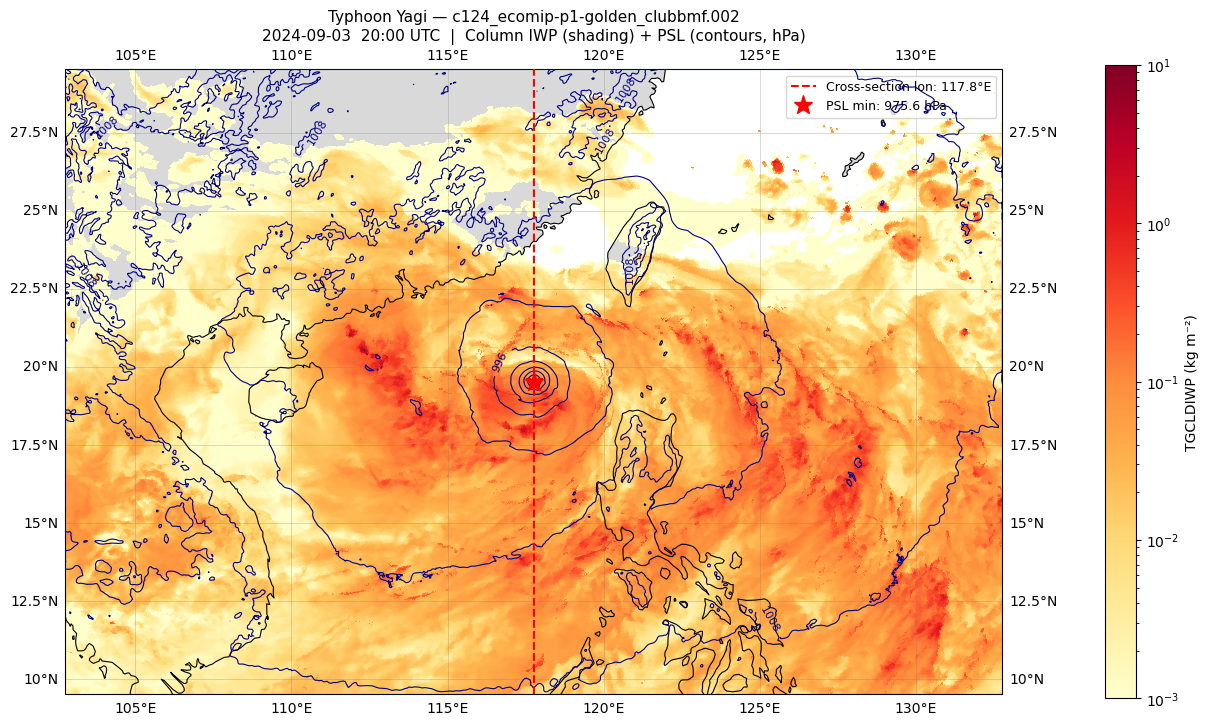

In [6]:
# ── Pre-extract overview region data (used by both UXarray and fallback paths) ─
_ov_lon_range = (LON_CENTER - 15.0, LON_CENTER + 15.0)
_ov_lat_range = (LAT_CENTER - 10.0, LAT_CENTER + 10.0)

_ov_mask = (
    (lon_all >= _ov_lon_range[0]) & (lon_all <= _ov_lon_range[1]) &
    (lat_all >= _ov_lat_range[0]) & (lat_all <= _ov_lat_range[1])
)
_lon_ov  = lon_all[_ov_mask]
_lat_ov  = lat_all[_ov_mask]
_psl_ov  = ds_survey_snap["PSL"].isel(time=0).values[_ov_mask] / 100.0    # Pa → hPa
_iwp_ov  = ds_survey_snap["TGCLDIWP"].isel(time=0).values[_ov_mask]       # kg m⁻²

print(f"Overview region: {_ov_mask.sum():,} cells")
print(f"PSL range:       {_psl_ov.min():.1f}–{_psl_ov.max():.1f} hPa")
print(f"TGCLDIWP range:  {_iwp_ov.min():.2e}–{_iwp_ov.max():.2e} kg m⁻²")

# PSL contour levels: every 4 hPa, adaptive to actual range
_psl_lo  = np.floor(_psl_ov.min() / 4) * 4
_psl_hi  = np.ceil( _psl_ov.max() / 4) * 4
_psl_levels = np.arange(_psl_lo, _psl_hi + 4, 4.0)

_iwp_norm = mcolors.LogNorm(vmin=1e-3, vmax=10.0)
_ov_extent = [_ov_lon_range[0], _ov_lon_range[1],
               _ov_lat_range[0], _ov_lat_range[1]]

# ── Attempt UXarray native-grid polygon plot ──────────────────────────────────
try:
    print("\nBuilding UXarray dataset (may take 1–3 min for 42M-cell grid)...")
    uxds_ov = ux.open_dataset(str(GRID_FILE), str(survey_path))

    _ux_iwp  = uxds_ov["TGCLDIWP"].isel(time=0)
    _ux_bbox = _ux_iwp.subset.bounding_box(_ov_lon_range, _ov_lat_range)
    _pc      = _ux_bbox.to_polycollection()
    _pc.set_antialiased(False)
    _pc.set_norm(_iwp_norm)
    _pc.set_cmap("YlOrRd")

    fig_ov, ax_ov = plt.subplots(
        figsize=(12, 8),
        subplot_kw={"projection": ccrs.PlateCarree()},
        constrained_layout=True,
    )
    ax_ov.set_extent(_ov_extent, crs=ccrs.PlateCarree())
    ax_ov.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=5)
    ax_ov.add_feature(cfeature.LAND, facecolor="0.85", zorder=0)
    ax_ov.add_collection(_pc)
    fig_ov.colorbar(_pc, ax=ax_ov, label="TGCLDIWP (kg m⁻²)", shrink=0.8)

    # PSL contours via tricontour (handles irregular scatter points)
    _ct_psl = ax_ov.tricontour(
        _lon_ov, _lat_ov, _psl_ov,
        levels=_psl_levels, colors="navy", linewidths=0.8, zorder=6,
    )
    ax_ov.clabel(_ct_psl, inline=True, fontsize=8, fmt="%.0f",
                 levels=_psl_levels[::3])

    ax_ov.axvline(x=LON_CENTER, color="red", linewidth=1.5, linestyle="--", zorder=7,
                  label=f"Cross-section lon: {LON_CENTER:.1f}°E")
    ax_ov.plot(LON_CENTER, LAT_CENTER, "r*", markersize=14, zorder=8,
               transform=ccrs.PlateCarree(),
               label=f"PSL min: {_best['psl_min']:.1f} hPa")
    ax_ov.legend(loc="upper right", fontsize=9)
    ax_ov.set_title(
        f"Typhoon Yagi — {CASE}\n"
        f"{TARGET_DATE}  {TARGET_SECONDS//3600:02d}:{(TARGET_SECONDS%3600)//60:02d} UTC  |  "
        f"Column IWP (shading) + PSL (contours, hPa)",
        fontsize=11,
    )
    ax_ov.gridlines(draw_labels=True, linewidth=0.4, color="gray", alpha=0.5)
    plt.show()

except Exception as _e:
    # ── Scatter / tricontourf fallback ────────────────────────────────────────
    print(f"UXarray path skipped ({type(_e).__name__}: {_e})")
    print("Using scatter + tricontour fallback.")

    fig_ov, ax_ov = plt.subplots(
        figsize=(12, 8),
        subplot_kw={"projection": ccrs.PlateCarree()},
        constrained_layout=True,
    )
    ax_ov.set_extent(_ov_extent, crs=ccrs.PlateCarree())
    ax_ov.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=5)
    ax_ov.add_feature(cfeature.LAND, facecolor="0.85", zorder=0)

    _sc = ax_ov.scatter(
        _lon_ov, _lat_ov, c=_iwp_ov, s=0.3,
        cmap="YlOrRd", norm=_iwp_norm,
        rasterized=True, zorder=2, transform=ccrs.PlateCarree(),
    )
    _ct_psl = ax_ov.tricontour(
        _lon_ov, _lat_ov, _psl_ov,
        levels=_psl_levels, colors="navy", linewidths=0.8, zorder=6,
    )
    ax_ov.clabel(_ct_psl, inline=True, fontsize=8, fmt="%.0f",
                 levels=_psl_levels[::3])

    fig_ov.colorbar(_sc, ax=ax_ov, label="TGCLDIWP (kg m⁻²)", shrink=0.8)
    ax_ov.axvline(x=LON_CENTER, color="red", linewidth=1.5, linestyle="--", zorder=7,
                  label=f"Cross-section lon: {LON_CENTER:.1f}°E")
    ax_ov.plot(LON_CENTER, LAT_CENTER, "r*", markersize=14, zorder=8,
               transform=ccrs.PlateCarree(),
               label=f"PSL min: {_best['psl_min']:.1f} hPa")
    ax_ov.legend(loc="upper right", fontsize=9)
    ax_ov.set_title(
        f"Typhoon Yagi — {CASE}  (scatter fallback)\n"
        f"{TARGET_DATE}  {TARGET_SECONDS//3600:02d}:{(TARGET_SECONDS%3600)//60:02d} UTC  |  "
        f"Column IWP + PSL (hPa)",
        fontsize=11,
    )
    ax_ov.gridlines(draw_labels=True, linewidth=0.4, color="gray", alpha=0.5)
    plt.show()

## Extract North–South Curtain

Algorithm:
1. Select all MPAS columns within `LON_CENTER ± LON_HALF_WIDTH` and `LAT_RANGE`.
   A date-line–safe shift is applied before the comparison.
2. Load CLDLIQ, CLDICE, Z3, T **only for the selected columns** — avoids reading
   the full 41.9M-column arrays.
3. Sort columns by latitude (south → north).
4. Build pcolormesh boundary arrays: `ilev` (59 interface heights) for the y-axis
   and midpoint-interpolated lat bounds for the x-axis.
5. Replace exact zeros with NaN for clean log-scale rendering.

In [7]:
# ── 1. Longitude band mask (date-line–safe) ────────────────────────────────────
_lon_norm = lon_all % 360.0
_lon_c    = LON_CENTER % 360.0
_shift       = 180.0 - _lon_c
_lon_shifted = (_lon_norm + _shift) % 360.0
_center_s    = 180.0

cell_mask = (
    (np.abs(_lon_shifted - _center_s) < LON_HALF_WIDTH) &
    (lat_all > LAT_RANGE[0]) &
    (lat_all < LAT_RANGE[1])
)

n_cells = int(cell_mask.sum())
print(f"Cross-section band: {n_cells:,} cells")
print(f"  lon: {LON_CENTER:.2f}°E ± {LON_HALF_WIDTH:.1f}°")
print(f"  lat: {LAT_RANGE[0]:.1f}°N – {LAT_RANGE[1]:.1f}°N")
if n_cells < 50:
    print("WARNING: very few cells — consider widening LON_HALF_WIDTH")

# ── 2. Extract 3D variables for curtain columns (safe to .compute()) ──────────
# Each variable: shape (58, n_cells) — 58 levels × ~60k cells ≈ 14 MB per variable
lat_sub = lat_all[cell_mask]

cldliq_raw = ds["CLDLIQ"].isel(time=0).values[:, cell_mask]   # (58, n_cells)
cldice_raw = ds["CLDICE"].isel(time=0).values[:, cell_mask]
z3_raw     = ds["Z3"].isel(time=0).values[:, cell_mask]
t_raw      = ds["T"].isel(time=0).values[:, cell_mask]

print(f"\nExtracted shape: {cldliq_raw.shape}  (lev=58, n_cells={n_cells:,})")
print(f"CLDLIQ: max={cldliq_raw.max():.2e} kg/kg  nonzero={int(np.sum(cldliq_raw>0)):,}")
print(f"CLDICE: max={cldice_raw.max():.2e} kg/kg  nonzero={int(np.sum(cldice_raw>0)):,}")
print(f"T:      {t_raw.min():.1f}–{t_raw.max():.1f} K")
print(f"Z3:     {z3_raw.min():.0f}–{z3_raw.max():.0f} m")

# ── 3. Sort columns south → north ─────────────────────────────────────────────
sidx = np.argsort(lat_sub)
lat_s    = lat_sub[sidx]
cldliq_s = cldliq_raw[:, sidx]
cldice_s = cldice_raw[:, sidx]
z3_s     = z3_raw[:, sidx]
t_s      = t_raw[:, sidx]

# ── 4. Mask true zeros → NaN for log-scale rendering ──────────────────────────
cldliq_plot = np.where(cldliq_s > 0, cldliq_s, np.nan)
cldice_plot = np.where(cldice_s > 0, cldice_s, np.nan)

# ── 5. Build pcolormesh boundary coordinates ───────────────────────────────────
# y-axis: ilev (59 interface heights, top-to-bottom; ilev[-1]≈0 m at surface)
ilev_vals = ds["ilev"].values   # shape (59,)

# x-axis: latitude boundaries — midpoints between adjacent cell centers
lat_b = np.concatenate([
    [lat_s[0]  - 0.5 * (lat_s[1]  - lat_s[0])],
    0.5 * (lat_s[:-1] + lat_s[1:]),
    [lat_s[-1] + 0.5 * (lat_s[-1] - lat_s[-2])],
])  # shape: (n_cells+1,)

# 2D boundary meshgrid: shape (59, n_cells+1) — one larger than data in each dim
lat_2d, ilev_2d = np.meshgrid(lat_b, ilev_vals)

print(f"\nBoundary grids: lat_2d={lat_2d.shape}, ilev_2d={ilev_2d.shape}")
print(f"Data arrays:    {cldliq_s.shape}  ✓ (rows-1, cols-1) relative to boundaries")

Cross-section band: 61,362 cells
  lon: 117.76°E ± 2.0°
  lat: 11.5°N – 27.5°N

Extracted shape: (58, 61362)  (lev=58, n_cells=61,362)
CLDLIQ: max=2.90e-03 kg/kg  nonzero=585,183
CLDICE: max=1.35e-03 kg/kg  nonzero=1,993,420
T:      185.8–304.9 K
Z3:     35–41138 m

Boundary grids: lat_2d=(59, 61363), ilev_2d=(59, 61363)
Data arrays:    (58, 61362)  ✓ (rows-1, cols-1) relative to boundaries


## Cross-Section: Cloud Liquid and Ice

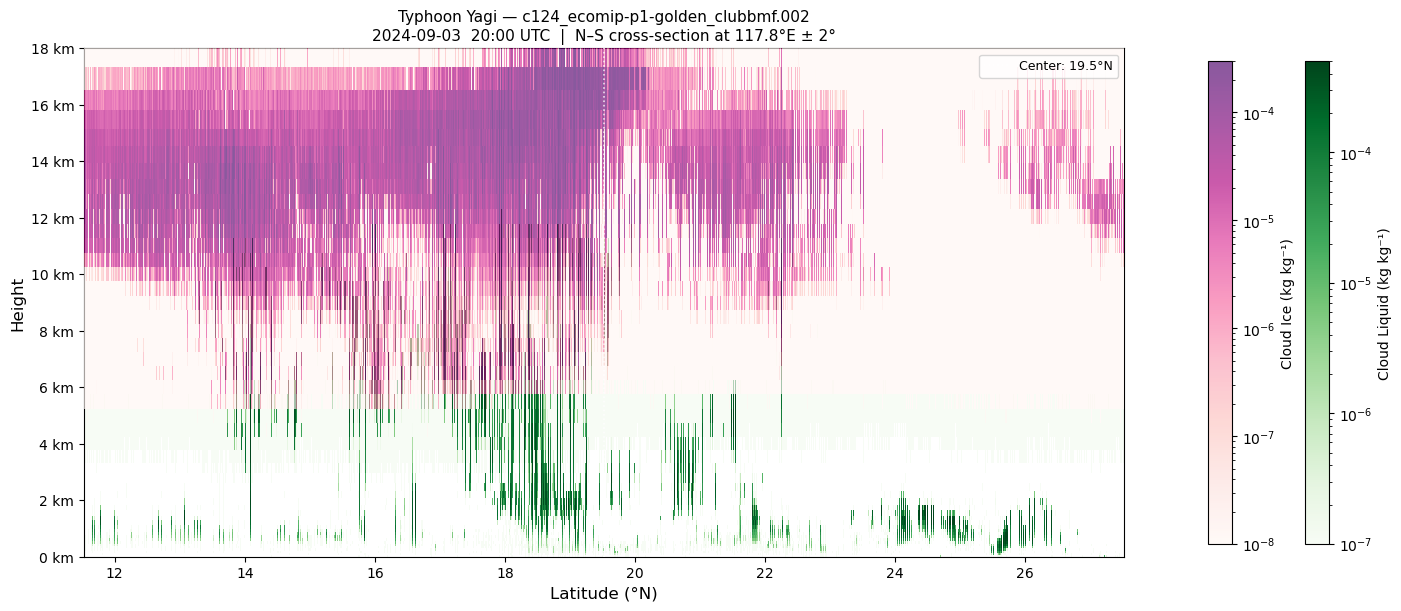

In [8]:
liq_norm = mcolors.LogNorm(vmin=1e-7, vmax=5e-4)
ice_norm = mcolors.LogNorm(vmin=1e-8, vmax=3e-4)

fig, ax = plt.subplots(figsize=(14, 6), constrained_layout=True)

# Cloud liquid water — green
im_liq = ax.pcolormesh(
    lat_2d, ilev_2d, cldliq_plot,
    cmap="Greens", norm=liq_norm,
    shading="flat", zorder=2,
)

# Cloud ice water — pink/purple, semi-transparent overlay
im_ice = ax.pcolormesh(
    lat_2d, ilev_2d, cldice_plot,
    cmap="RdPu", norm=ice_norm,
    shading="flat", alpha=0.65, zorder=3,
)

# Mark the typhoon center latitude
ax.axvline(x=LAT_CENTER, color="white", linewidth=1.2, linestyle=":",
           alpha=0.8, zorder=4, label=f"Center: {LAT_CENTER:.1f}°N")

# Axes
ax.set_xlim(LAT_RANGE)
ax.set_ylim(0, ALT_MAX)
ax.set_xlabel("Latitude (°N)", fontsize=12)
ax.set_ylabel("Height", fontsize=12)
ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f} km")
)
ax.legend(loc="upper right", fontsize=9)

ax.set_title(
    f"Typhoon Yagi — {CASE}\n"
    f"{TARGET_DATE}  {TARGET_SECONDS//3600:02d}:{(TARGET_SECONDS%3600)//60:02d} UTC  |  "
    f"N–S cross-section at {LON_CENTER:.1f}°E ± {LON_HALF_WIDTH:.0f}°",
    fontsize=11,
)

fig.colorbar(im_liq, ax=ax, location="right", pad=0.01, shrink=0.95,
             label="Cloud Liquid (kg kg⁻¹)")
fig.colorbar(im_ice, ax=ax, location="right", pad=0.08, shrink=0.95,
             label="Cloud Ice (kg kg⁻¹)")
plt.show()

## Cross-Section with Temperature Contours and Tropopause

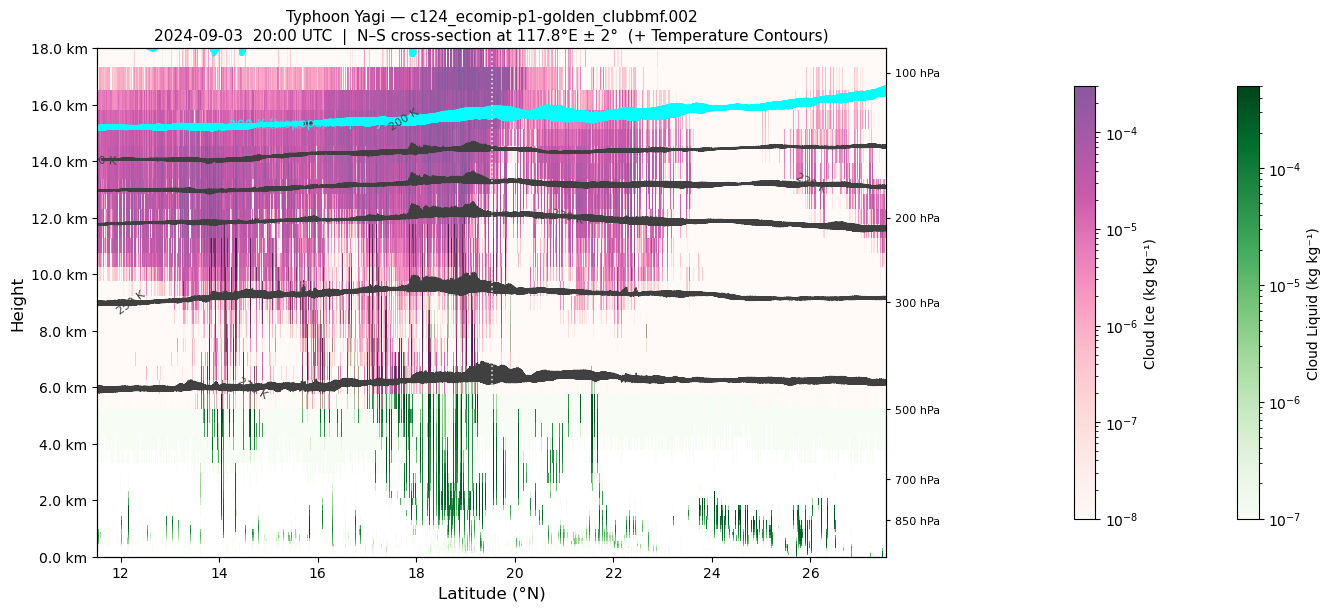

In [9]:
# Approximate pressure level heights for secondary y-axis labels
# Using scale height H ≈ 7.4 km:  z = H × ln(P0/P)
_std_hpa   = np.array([850, 700, 500, 300, 200, 100, 50])
_std_hpa_h = 7400.0 * np.log(1013.25 / _std_hpa)
_in_range  = _std_hpa_h <= ALT_MAX

fig, ax = plt.subplots(figsize=(14, 6), constrained_layout=True)

# ── Cloud water layers (same as above) ────────────────────────────────────────
im_liq = ax.pcolormesh(lat_2d, ilev_2d, cldliq_plot,
                        cmap="Greens", norm=liq_norm, shading="flat", zorder=2)
im_ice = ax.pcolormesh(lat_2d, ilev_2d, cldice_plot,
                        cmap="RdPu", norm=ice_norm, shading="flat", alpha=0.65, zorder=3)

# ── Temperature contours using actual geopotential heights (Z3) ───────────────
# Using Z3 as the y-axis (not the nominal ilev) correctly shows the warm-core
# displacement: in the typhoon eye, pressure levels are lifted by ~100–500 m.
_lat_2d_ctr = np.tile(lat_s, (len(ds["lev"]), 1))   # (58, n_cells) — same shape as t_s

ct_t = ax.contour(
    _lat_2d_ctr, z3_s, t_s,
    levels=[200, 210, 220, 230, 250, 270],
    colors="0.25", linewidths=0.7, linestyles="--", zorder=4,
)
ax.clabel(ct_t, inline=True, fontsize=8, fmt="%d K")

# T=200 K tropopause proxy (tropical cold-point tropopause ~16–17 km)
ct_trop = ax.contour(
    _lat_2d_ctr, z3_s, t_s,
    levels=[200], colors="cyan", linewidths=2.0, linestyles="-", zorder=5,
)
ax.clabel(ct_trop, inline=True, fontsize=9, fmt="200 K (tropopause proxy)")

# Typhoon center marker
ax.axvline(x=LAT_CENTER, color="white", linewidth=1.2, linestyle=":",
           alpha=0.8, zorder=6)

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xlim(LAT_RANGE)
ax.set_ylim(0, ALT_MAX)
ax.set_xlabel("Latitude (°N)", fontsize=12)
ax.set_ylabel("Height", fontsize=12)
ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, _: f"{x/1000:.1f} km")
)

# Secondary y-axis with approximate pressure labels
ax2 = ax.twinx()
ax2.set_ylim(0, ALT_MAX)
ax2.set_yticks(_std_hpa_h[_in_range])
ax2.set_yticklabels([f"{p} hPa" for p in _std_hpa[_in_range]], fontsize=8)
ax2.tick_params(axis="y", length=3)

ax.set_title(
    f"Typhoon Yagi — {CASE}\n"
    f"{TARGET_DATE}  {TARGET_SECONDS//3600:02d}:{(TARGET_SECONDS%3600)//60:02d} UTC  |  "
    f"N–S cross-section at {LON_CENTER:.1f}°E ± {LON_HALF_WIDTH:.0f}°  "
    "(+ Temperature Contours)",
    fontsize=11,
)

fig.colorbar(im_liq, ax=[ax, ax2], location="right", pad=0.10, shrink=0.85,
             label="Cloud Liquid (kg kg⁻¹)")
fig.colorbar(im_ice, ax=[ax, ax2], location="right", pad=0.17, shrink=0.85,
             label="Cloud Ice (kg kg⁻¹)")
plt.show()

## Notes on Interpretation

**Storm context**: The simulation captures Typhoon Yagi as it crossed Luzon (~Sept 2)
and entered the South China Sea (Sept 3). The simulated PSL minimum represents
the model intensity at this stage — weaker than Yagi's observed peak of ~907 hPa on Sept 5,
which occurs after the simulation ends.

**Cross-section geometry**: The N–S curtain at the detected center longitude slices through
the typhoon's core. Each MPAS column has a nominal spacing of ~3.75 km, so the curtain
reveals eyewall convection, spiral rainbands, and the warm-core structure.

**Cloud structure**:
- **Green** (CLDLIQ): liquid-phase cloud in the lower-to-mid troposphere — low-level inflow,
  rain shaft regions, and warm-cloud rainbands.
- **Pink/purple** (CLDICE): ice-phase cloud in the upper troposphere — cirrus anvil outflow,
  deep convective tops, and the broad ice canopy of the typhoon.

**Vertical axis**: Height in km (left) with approximate pressure levels (right).
The cyan T = 200 K isotherm marks the cold-point tropopause (~16–17 km in the tropics).
Deep convective towers reaching or overshooting the tropopause are a signature of
intense organized convection.

**Temperature contours vs. height coordinates**: The temperature contours use
`Z3` (actual geopotential heights) as the y-coordinate, while the cloud pcolormesh
uses `ilev` (nominal interface heights). In the typhoon warm core, `Z3` is elevated
by ~100–500 m compared to the environment — correctly reflecting the warm-core structure.

**To explore further**: Change `LON_HALF_WIDTH` to widen the curtain, adjust `LAT_RANGE`
to zoom in on the eyewall, or re-run from Cell 8 with a different timestep from the
tracking table in Cell 4.